# Diabetes prediction - Module 2: Model building & feature engineering

This module uses Module 1's saved, cleaned data (`train_cleaned.csv`, `test_cleaned.csv`) directly, instead of redoing the split and cleasing from scratch

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import joblib

In [66]:
sns.set_theme(style='whitegrid')

## Loading Module 1's clean train/test data

In [67]:
train_df = pd.read_csv('C:/Users/Priyanshu/Projects/mentorminds/diabetes_onset_prediction/data/train_cleaned.csv')
test_df = pd.read_csv('C:/Users/Priyanshu/Projects/mentorminds/diabetes_onset_prediction/data/test_cleaned.csv')

In [68]:
diagnostic_features = [c for c in train_df.columns if c != 'Outcome']

x_train = train_df[diagnostic_features]
y_train = train_df['Outcome']
x_test = test_df[diagnostic_features]
y_test = test_df['Outcome']

print("Train shape:", x_train.shape, "Test shape:", x_test.shape)
train_df.head()

Train shape: (614, 10) Test shape: (154, 10)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insulin_missing,SkinThickness_missing,Outcome
0,1.0,90.0,62.0,12.0,43.0,27.2,0.580,24.0,0,0,0
1,5.0,126.0,78.0,27.0,22.0,29.6,0.439,40.0,0,0,0
2,2.0,105.0,58.0,40.0,94.0,34.9,0.225,25.0,0,0,0
3,1.0,146.0,56.0,29.0,125.0,29.7,0.564,29.0,1,1,0
4,0.0,95.0,64.0,39.0,105.0,44.6,0.366,22.0,0,0,0


## Running four baseline claissifiers and storing their accuracy

No scaling or feature engineering yet. models fitted on baseline data.

+ Logistic Regression
+ KNN
+ Decision Tree
+ Random Forest

In [69]:
def evaluate_models(models_dict, x_tr, x_te, y_tr, y_te, stage_name):
    # Fitting each models and recording its accuracy and ROC-AUC for the stage
    rows = []
    for name, model in models_dict.items():
        model.fit(x_tr, y_tr)
        pred = model.predict(x_te)
        prob = model.predict_proba(x_te)[:, 1]
        rows.append({
            'Stage': stage_name,
            'Model': name,
            'Accuracy': accuracy_score(y_te, pred),
            'ROC-AUC': roc_auc_score(y_te, prob)
        })
    return rows


In [70]:
def make_models():
    # A set of the four models
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'KNN': KNeighborsClassifier(),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
    }


In [71]:
all_results = [] # results for every stages get appended here for comparision

baseline_results = evaluate_models(make_models(), x_train, x_test, y_train, y_test, "1. Baseline")
all_results += baseline_results
pd.DataFrame(baseline_results)

,Stage,Model,Accuracy,ROC-AUC
0,1. Baseline,Logistic Regression,0.694805,0.818333
1,1. Baseline,KNN,0.688312,0.718056
2,1. Baseline,Decision Tree,0.662338,0.616481
3,1. Baseline,Random Forest,0.740260,0.815556


## Feature Engineering: MinMax Scaler vs Standard Scaler

+ **MinMaxScaler** squeezes every feature into the range [0, 1].
+ **StandardScaler** rescales every feature to have mean 0 and standard deviation 1.

Both are fitted in the training data only, then appleid to the test data to avoid leakage.

In [72]:
minmax = MinMaxScaler()
x_train_minmax = pd.DataFrame(minmax.fit_transform(x_train), columns=diagnostic_features, index=x_train.index)
x_test_minmax = pd.DataFrame(minmax.transform(x_test), columns=diagnostic_features, index=x_test.index)

minmax_results = evaluate_models(make_models(), x_train_minmax, x_test_minmax, y_train, y_test, '2. MinMax Scaled')
all_results += minmax_results

pd.DataFrame(minmax_results)

,Stage,Model,Accuracy,ROC-AUC
0,2. MinMax Scaled,Logistic Regression,0.707792,0.813704
1,2. MinMax Scaled,KNN,0.681818,0.764259
2,2. MinMax Scaled,Decision Tree,0.662338,0.620741
3,2. MinMax Scaled,Random Forest,0.740260,0.814167


In [73]:
standard = StandardScaler()
x_train_standard = pd.DataFrame(standard.fit_transform(x_train), columns=diagnostic_features, index=x_train.index)
x_test_standard = pd.DataFrame(standard.transform(x_test), columns=diagnostic_features, index=x_test.index)
standard_results = evaluate_models(make_models(), x_train_standard, x_test_standard, y_train, y_test, '3. Standard Scaled')
all_results += standard_results

pd.DataFrame(standard_results)

,Stage,Model,Accuracy,ROC-AUC
0,3. Standard Scaled,Logistic Regression,0.701299,0.818148
1,3. Standard Scaled,KNN,0.720779,0.762407
2,3. Standard Scaled,Decision Tree,0.662338,0.620741
3,3. Standard Scaled,Random Forest,0.740260,0.817500


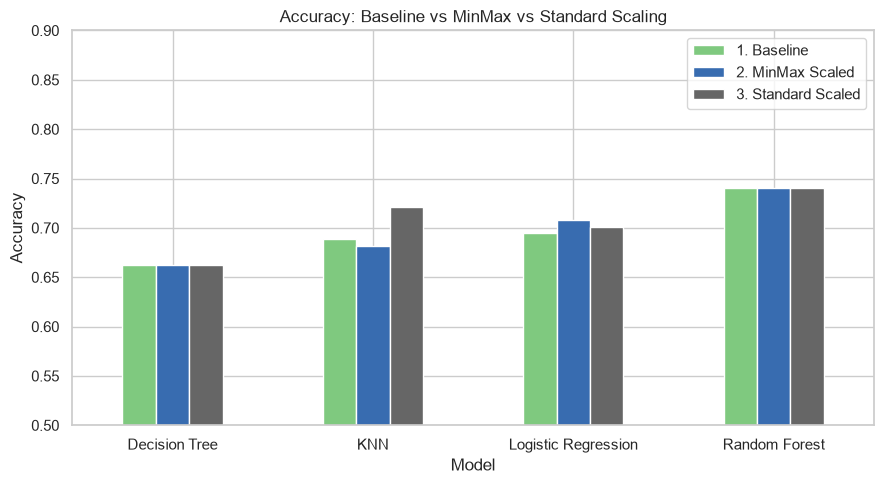

Stage,1. Baseline,2. MinMax Scaled,3. Standard Scaled
Model,,,
Decision Tree,0.662338,0.662338,0.662338
KNN,0.688312,0.681818,0.720779
Logistic Regression,0.694805,0.707792,0.701299
Random Forest,0.740260,0.740260,0.740260


In [74]:
# Visually comparing all the three stages
compare_df = pd.DataFrame(all_results)
compare_df_pivot = compare_df.pivot(index='Model', columns='Stage', values='Accuracy')
compare_df_pivot = compare_df_pivot[['1. Baseline', '2. MinMax Scaled', '3. Standard Scaled']]

compare_df_pivot.plot(kind='bar', figsize=(9, 5), colormap='Accent')
plt.title('Accuracy: Baseline vs MinMax vs Standard Scaling')
plt.ylabel('Accuracy')
plt.ylim(0.5, 0.9)
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

compare_df_pivot

+ **KNN**: Minimal change with MinMax (0.688 -> 0.682), but clear imprvement was seen with Standard scaling (0.688 -> 0.721). Scaling helped, but only one of the two scalers, aand the other one slighly hurt.
+ **Logistic Regression**: Though modest, improvement was seen with both MinMax scaler (0.695 -> 0.708) and Standard scaler (0.695 -> 0.701).
+ **Decision Tree and Random Forest**: No changes seen, since tree splits are unaffected by feature scales.

In [75]:
def trees_identical(rf_a, rf_b):
    n_diff = 0
    for ta, tb in zip(rf_a.estimators_, rf_b.estimators_):
        fa, fb = ta.tree_.feature, tb.tree_.feature
        if len(fa) != len(fb) or not np.array_equal(fa, fb):
            n_diff += 1
    return n_diff

rf_raw = RandomForestClassifier(n_estimators=100, random_state=42).fit(x_train, y_train)
rf_mm = RandomForestClassifier(n_estimators=100, random_state=42).fit(x_train_minmax, y_train)

print("Trees that differ, raw vs MinMax:", trees_identical(rf_raw, rf_mm), "/ 100")

Trees that differ, raw vs MinMax: 0 / 100


**Picking a scaler to move forward:** whichever scaler gives the higher average accuracy across all four models will be used from here on.

In [76]:
minmax_avg = compare_df_pivot['2. MinMax Scaled'].mean()
standard_avg = compare_df_pivot['3. Standard Scaled'].mean()

print(f'Average accuracy — MinMax: {minmax_avg:.4f}')
print(f'Average accuracy — Standard: {standard_avg:.4f}')

if standard_avg >= minmax_avg:
    best_scaler_name = 'Standard'
    x_train_scaled, x_test_scaled = x_train_standard, x_test_standard
else:
    best_scaler_name = 'MinMax'
    x_train_scaled, x_test_scaled = x_train_minmax, x_test_minmax

print(f'\nUsing {best_scaler_name} scaling going forward')

Average accuracy — MinMax: 0.6981
Average accuracy — Standard: 0.7062

Using Standard scaling going forward


## Feature Engineering: Choosing the top features

+ **Correlation with Outcome** — how strongly each feature moves together with target.
+ **Random Forest feature importance** — how much each feature helped the tree split patients correctly. This can pick up interaction effects that a correlation number misses.

In [77]:
correlation = train_df[diagnostic_features + ['Outcome']].corr()['Outcome'].drop('Outcome')
correlation = correlation.sort_values(key=abs, ascending=False)
print('Correlation with Outcome:')
print(correlation.round(3))

Correlation with Outcome:
Glucose                     0.512
BMI                         0.330
Insulin                     0.272
Age                         0.246
SkinThickness               0.234
Pregnancies                 0.207
BloodPressure               0.188
DiabetesPedigreeFunction    0.178
SkinThickness_missing       0.045
Insulin_missing             0.027
Name: Outcome, dtype: float64


In [78]:
rf_for_imp = RandomForestClassifier(n_estimators=300, random_state=42)
rf_for_imp.fit(x_train_scaled, y_train)

importance = pd.Series(rf_for_imp.feature_importances_, index=diagnostic_features)
importance = importance.sort_values(ascending=False)
print('Random Forest feature importance:')
print(importance.round(3))

Random Forest feature importance:
Glucose                     0.276
BMI                         0.158
Age                         0.125
DiabetesPedigreeFunction    0.118
Insulin                     0.083
Pregnancies                 0.077
BloodPressure               0.075
SkinThickness               0.067
SkinThickness_missing       0.011
Insulin_missing             0.010
dtype: float64


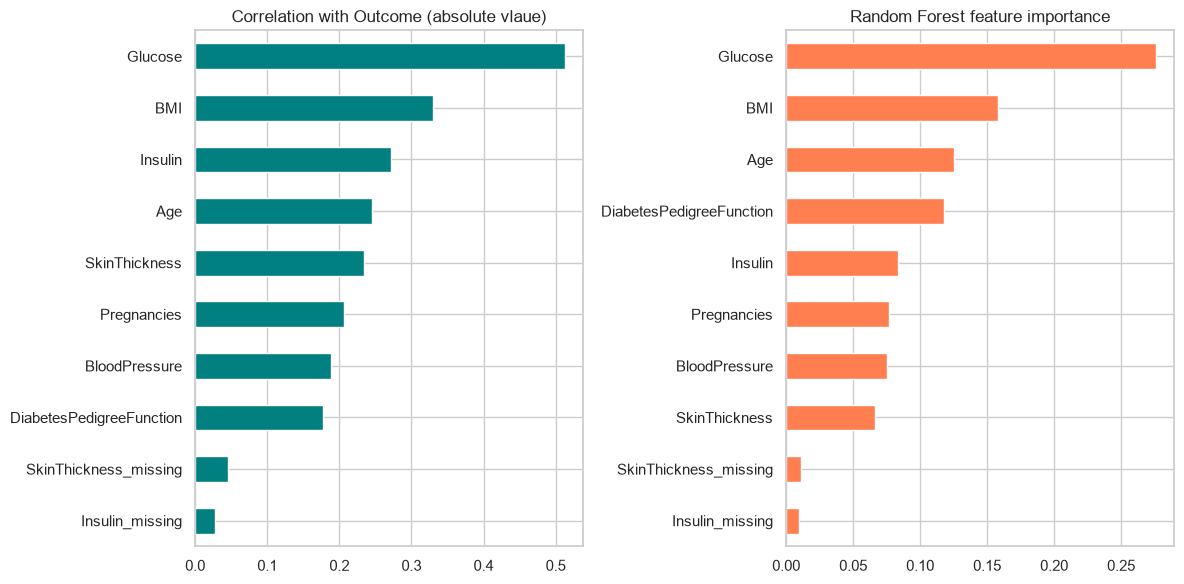

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
correlation.abs().sort_values().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Correlation with Outcome (absolute vlaue)')
importance.sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Random Forest feature importance')
plt.tight_layout()
plt.show()

### Chosen features and their reason:

Based on the evidence above, we have **five features**: `Glucose`, `BMI`, `Age`, `DiabetesPedigreeFunction`, and `Insulin`.

+ **Glucose** → the top feature on both correlation and RF importance measures. This also matches medical reality: elevated blood glucose is the main diagnostic criterion for diabetes.
+ **BMI** → second highest feature on both measures. Higher BMI is a well established diagnostic criterion for insulin resistance, which leads to diabetes.
+ **Age** → third highest feature in random forest and the fourth highest feature in correlation. Diabetes risk increases with age as insulin sensitivity naturally declines over time.
+ **DiabetesPedigreeFunction** → though the feature is ranked by simpple correlation, it is ranked fourth by Random Forest importance. The gap suggests that the featur's relationship with the outcome is .more non-linear. Moreover, genetic/family history of diabetes is a real world medical diagnostic feature of diabetes.
+ **Insulin** → third by correlation though fifth by importance. However, diabetes is fundamentally a disorder of insulin regulation, so it is one of the most important diagnostic feature for diabetes prediction.

In [80]:
selected_features = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Insulin']

x_train_selected = x_train_scaled[selected_features]
x_test_selected = x_test_scaled[selected_features]

selected_results = evaluate_models(make_models(), x_train_selected, x_test_selected, y_train, y_test, f'4. Top 5 Features ({best_scaler_name} Scaled)')
all_results += selected_results

pd.DataFrame(selected_results)

,Stage,Model,Accuracy,ROC-AUC
0,4. Top 5 Features (Standard Scaled),Logistic Regression,0.727273,0.796111
1,4. Top 5 Features (Standard Scaled),KNN,0.701299,0.785463
2,4. Top 5 Features (Standard Scaled),Decision Tree,0.655844,0.615741
3,4. Top 5 Features (Standard Scaled),Random Forest,0.759740,0.812685


### Further tuning methods:
+ **Hyperparameter tuning** 
+ **Class weighting** — to address the 65/35 imbalance.

In [81]:
param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10]},
    'KNN': {'n_neighbors': [3, 2, 7, 9, 11]},
    'Decision Tree': {'max_depth': [3, 5, 7, None]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}
}


In [82]:
tuned_models = {}
tuned_results = []

for name, model in make_models().items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='accuracy')
    grid.fit(x_train_selected, y_train)
    tuned_models[name] = grid.best_estimator_
    print(f'{name}: best params = {grid.best_params_}')

    preds = grid.best_estimator_.predict(x_test_selected)
    proba = grid.best_estimator_.predict_proba(x_test_selected)[:, 1]
    tuned_results.append({
        'Stage': '5. Hyperparameter Tuned',
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

all_results += tuned_results
pd.DataFrame(tuned_results)

Logistic Regression: best params = {'C': 0.1}
KNN: best params = {'n_neighbors': 11}
Decision Tree: best params = {'max_depth': 3}
Random Forest: best params = {'max_depth': 5, 'n_estimators': 100}


,Stage,Model,Accuracy,ROC-AUC
0,5. Hyperparameter Tuned,Logistic Regression,0.720779,0.794630
1,5. Hyperparameter Tuned,KNN,0.746753,0.821389
2,5. Hyperparameter Tuned,Decision Tree,0.688312,0.764074
3,5. Hyperparameter Tuned,Random Forest,0.740260,0.817963


In [83]:
# Class-weighting experiment (KNN excluded -- it has no class_weight option)
from sklearn.base import clone

balanced_models = {
    "Logistic Regression": clone(tuned_models["Logistic Regression"]).set_params(class_weight="balanced"),
    "Decision Tree": clone(tuned_models["Decision Tree"]).set_params(class_weight="balanced"),
    "Random Forest": clone(tuned_models["Random Forest"]).set_params(class_weight="balanced"),
}

balanced_results = evaluate_models(
    balanced_models, x_train_selected, x_test_selected, y_train, y_test, "6. Balanced Class Weights"
)
all_results += balanced_results

pd.DataFrame(balanced_results)


,Stage,Model,Accuracy,ROC-AUC
0,6. Balanced Class Weights,Logistic Regression,0.727273,0.795741
1,6. Balanced Class Weights,Decision Tree,0.675325,0.762130
2,6. Balanced Class Weights,Random Forest,0.759740,0.823704


**Comparison between Stage 6 and 5 (Hyperparameter tuned):**

+ **Logistic Regression**: accuracy increased (0.721 → 0.727), negligible increase in ROC-AUC (0.795 → 0.796).
+ **Decision Tree**: accuracy declined slightly (0.688 → 0.675), ROC-AUC also declined slightly (0.764 → 0.762).
+ **Random Forest**: accuracy increased (0.740 → 0.760), ROC-AUC improved (0.818 → 0.824)

## Final comparison: every stage, side by side

In [84]:
final_df = pd.DataFrame(all_results)
final_df = final_df.drop_duplicates(subset=['Stage', 'Model'], keep='last').reset_index(drop=True)
final_pivot = final_df.pivot(index='Model', columns='Stage', values='Accuracy')

stage_order = [s for s in [
    '1. Baseline',
    '2. MinMax Scaled',
    '3. Standard Scaled',
    f'4. Top 5 Features ({best_scaler_name} Scaled)',
    '5. Hyperparameter Tuned',
    '6. Balanced Class Weights',
] if s in final_pivot.columns]
final_pivot = final_pivot[stage_order]

final_pivot


Stage,1. Baseline,2. MinMax Scaled,3. Standard Scaled,4. Top 5 Features (Standard Scaled),5. Hyperparameter Tuned,6. Balanced Class Weights
Model,,,,,,
Decision Tree,0.662338,0.662338,0.662338,0.655844,0.688312,0.675325
KNN,0.688312,0.681818,0.720779,0.701299,0.746753,NaN
Logistic Regression,0.694805,0.707792,0.701299,0.727273,0.720779,0.727273
Random Forest,0.740260,0.740260,0.740260,0.759740,0.740260,0.759740


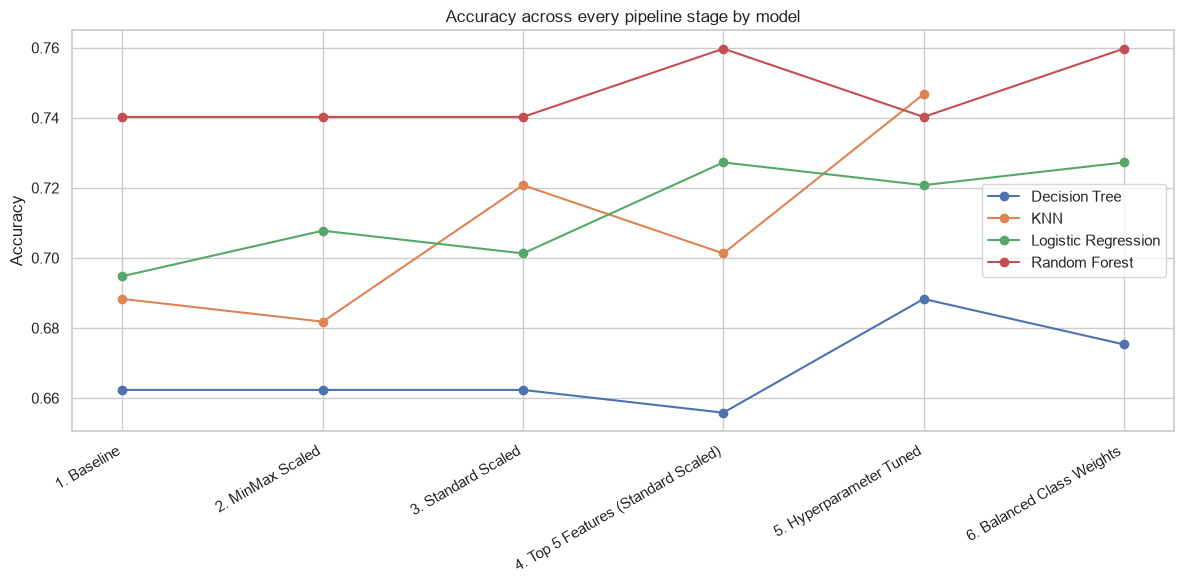

In [85]:
plt.figure(figsize=(12, 6))
for model_name in final_pivot.index:
    plt.plot(final_pivot.columns, final_pivot.loc[model_name], marker='o', label=model_name)

plt.xticks(rotation=30, ha='right')
plt.ylabel('Accuracy')
plt.title('Accuracy across every pipeline stage by model')
plt.legend()
plt.tight_layout()
plt.show()


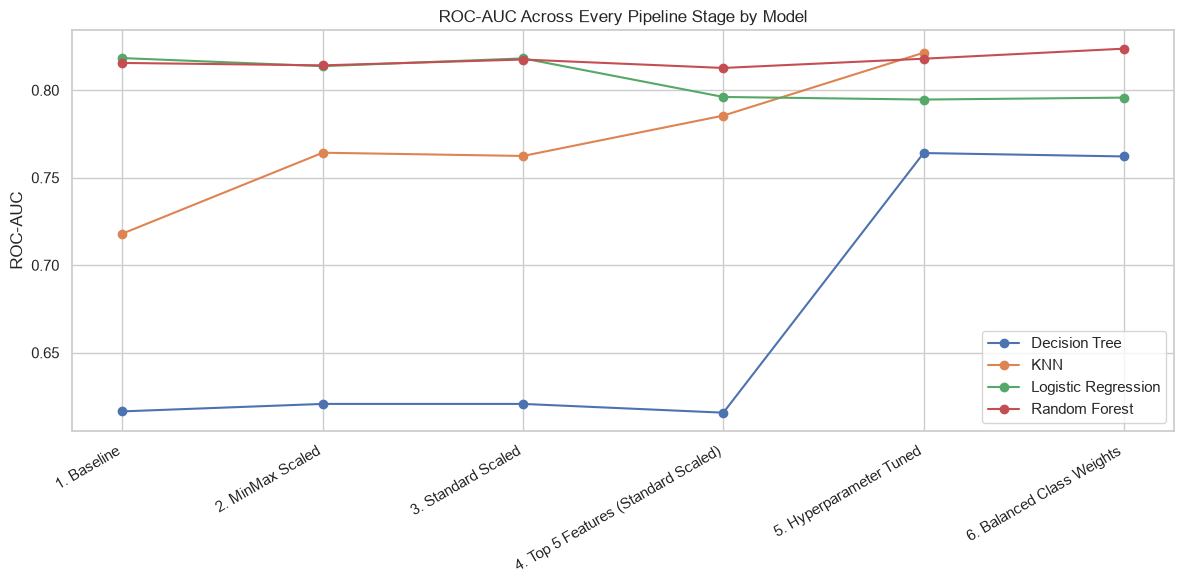

In [86]:
final_pivot_auc = final_df.pivot(index='Model', columns='Stage', values='ROC-AUC')[stage_order]

plt.figure(figsize=(12, 6))
for model_name in final_pivot_auc.index:
    plt.plot(final_pivot_auc.columns, final_pivot_auc.loc[model_name], marker='o', label=model_name)

plt.xticks(rotation=30, ha='right')
plt.ylabel('ROC-AUC')
plt.title('ROC-AUC Across Every Pipeline Stage by Model')
plt.legend()
plt.tight_layout()
plt.show()

## Saving the final models

Saving the hyperparameter-tuned models, along with the scaler and the selected feature list for evaluation in module 3 without the need of retraining the model again.

In [88]:
joblib.dump(tuned_models, 'models/final_models.joblib')
joblib.dump(standard if best_scaler_name == 'Standard' else minmax, 'models/scaler.joblib')
joblib.dump(selected_features, 'models/feature_cols.joblib')

print("Saved: models/final_models.joblib, models/scaler.joblib, models/feature_cols.joblib")


Saved: models/final_models.joblib, models/scaler.joblib, models/feature_cols.joblib


## Summary

+ Reused Module 1's saved, cleaned train/test data directly rather than derviing it again.
+ Ran four baseline classifiers (Logistic Regression, KNN, Decision Tree, Random Forest), then again with MinMax and Standard scaling.
+ Selected 5 diagnostic features (`Glucose`, `BMI`, `Age`, DiabetesPedigreeFunction`, `Insulin`) using both correlation and Random Forest importance, with reasoning tied to diabetes clinical
markers.
+ Explored further improvements: hyperparameter tuning via `GridSearchCV`, and class-weight balancing to address the 65/35 imbalance.
+ Reported ROC-AUC alongside Accuracy at every stage, since accuracy alone can be misleading on an imbalanced target.
+ Saved the final tuned models, scaler, and feature list for Module 3.